In [1]:
# Importamos las librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles

In [2]:
# Set the seed for reproducibility
np.random.seed(42)

In [3]:
# Creamos nuestros datos artificiales (dos círculos concéntricos)
X, Y = make_circles(n_samples=1000, factor=0.5, noise=0.05)

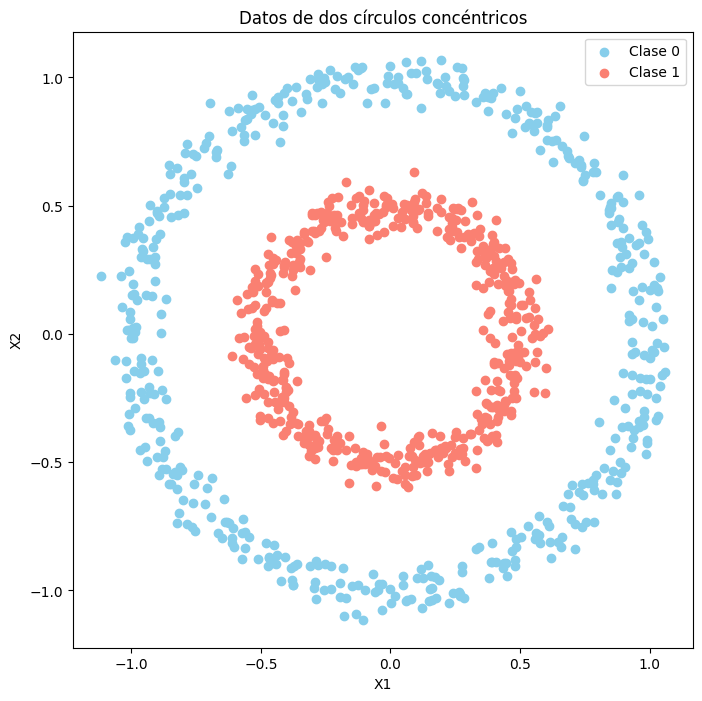

In [4]:
# Visualización de los datos generados
plt.figure(figsize=(8, 8))
plt.scatter(X[Y == 0, 0], X[Y == 0, 1], c="skyblue", label="Clase 0")
plt.scatter(X[Y == 1, 0], X[Y == 1, 1], c="salmon", label="Clase 1")
plt.title("Datos de dos círculos concéntricos")
plt.xlabel("X1")
plt.ylabel("X2")
plt.legend()
plt.show()

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.15, random_state=42)
print(f"Datos de entrenamiento: {X_train.shape[0]} muestras")
print(f"Datos de prueba: {X_test.shape[0]} muestras")

Datos de entrenamiento: 850 muestras
Datos de prueba: 150 muestras


In [6]:
#Como el modelo es de clasificación binomial, necesito usar sigmoid como funcion de activación y binary_crossentropy como función de pérdida, entrenar el modelo con 100 epocas con un bash size de 32, ademas quiero que uses 3 capas ocultas, la primera con 16 neuronas, la segunda con 8 y la tercera con 4 neuronas
from tensorflow import keras
from tensorflow.keras import layers

model = keras.Sequential([
    layers.Input(shape=(X_train.shape[1],)),
    layers.Dense(16, activation='relu'),
    layers.Dense(8, activation='relu'),
    layers.Dense(4, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [7]:
#Entrenamos el modelo
history = model.fit(X_train, y_train, epochs=100, batch_size=32, validation_data=(X_test, y_test))

Epoch 1/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 4s 60ms/step - accuracy: 0.4358 - loss: 0.7086 - val_accuracy: 0.2667 - val_loss: 0.6975
Epoch 2/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3505 - loss: 0.6959 - val_accuracy: 0.5000 - val_loss: 0.6927
Epoch 3/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4947 - loss: 0.6924 - val_accuracy: 0.5000 - val_loss: 0.6913
Epoch 4/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5039 - loss: 0.6899 - val_accuracy: 0.5000 - val_loss: 0.6881
Epoch 5/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4938 - loss: 0.6860 - val_accuracy: 0.5000 - val_loss: 0.6831
Epoch 6/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5199 - loss: 0.6781 - val_accuracy: 0.5000 - val_loss: 0.6764
Epoch 7/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5080 - loss: 0.6698 - val_accuracy: 0.5800 - val_loss: 0.6663
Epoch 8/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5935 - loss: 0.6533 - val_accuracy: 0.6200 - 

In [8]:
#Evaluamos el modelo
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Precisión en el conjunto de prueba: {test_acc:.4f}")
print(f" Pérdida en el conjunto de prueba: {test_loss:.4f}")

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 1.0000 - loss: 0.0593 
Precisión en el conjunto de prueba: 1.0000
 Pérdida en el conjunto de prueba: 0.0615


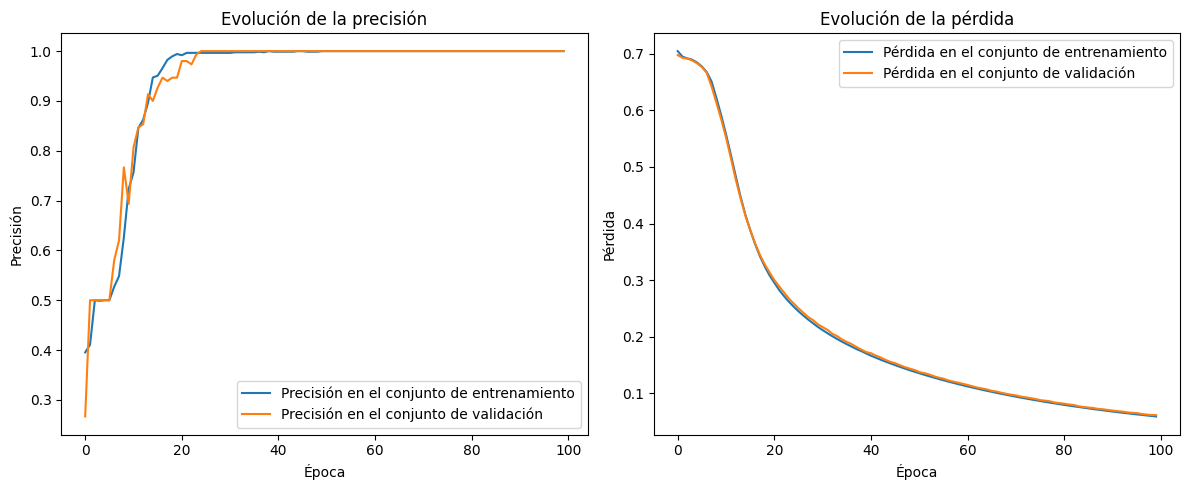

In [9]:
#Visualizamos la evolución de la precisión y la pérdida durante el entrenamiento
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Precisión en el conjunto de entrenamiento')
plt.plot(history.history['val_accuracy'], label='Precisión en el conjunto de validación')
plt.title('Evolución de la precisión')
plt.xlabel('Época')
plt.ylabel('Precisión')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Pérdida en el conjunto de entrenamiento')
plt.plot(history.history['val_loss'], label='Pérdida en el conjunto de validación')
plt.title('Evolución de la pérdida')
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.legend()

plt.tight_layout()
plt.show()